
# 🟢CodeAlpha Machine Learning Internship - Task 1 ( Credit Scoring Model)
_______________
Objective:
    Predict an individual's creditworthiness (good/bad credit risk) using
    past financial data such as income, debts, and payment history.
_______
Dataset:
    UCI Statlog (German Credit Data)
    https://archive.ics.uci.edu/dataset/144/statlog+german+credit+data
_____________

Models used:
    - Logistic Regression
    - Random Forest Classifier
_________
Evaluation:
    - Precision, Recall, F1-Score
    - ROC-AUC
    - Confusion Matrix
    - ROC Curve plot
"""

 Loaded REAL dataset: UCI German Credit Data

Dataset shape: (1000, 21)
  checking_account  duration credit_history purpose  credit_amount  \
0              A11         6            A34     A43           1169   
1              A12        48            A32     A43           5951   
2              A14        12            A34     A46           2096   
3              A11        42            A32     A42           7882   
4              A11        24            A33     A40           4870   

  savings_account employment_since  installment_rate personal_status_sex  \
0             A65              A75                 4                 A93   
1             A61              A73                 2                 A92   
2             A61              A74                 2                 A93   
3             A61              A74                 2                 A93   
4             A61              A73                 3                 A93   

  other_debtors  ...  property age  other_installm

,checking_account,duration,credit_history,purpose,credit_amount,savings_account,employment_since,installment_rate,personal_status_sex,other_debtors,...,property,age,other_installment_plans,housing,existing_credits,job,num_dependents,own_telephone,foreign_worker,target
0,A11,6,A34,A43,1169,A65,A75,4,A93,A101,...,A121,67,A143,A152,2,A173,1,A192,A201,0
1,A12,48,A32,A43,5951,A61,A73,2,A92,A101,...,A121,22,A143,A152,1,A173,1,A191,A201,1
2,A14,12,A34,A46,2096,A61,A74,2,A93,A101,...,A121,49,A143,A152,1,A172,2,A191,A201,0
3,A11,42,A32,A42,7882,A61,A74,2,A93,A103,...,A122,45,A143,A153,1,A173,2,A191,A201,0
4,A11,24,A33,A40,4870,A61,A73,3,A93,A101,...,A124,53,A143,A153,2,A173,2,A191,A201,1



===== Logistic Regression =====
Precision : 0.627
Recall    : 0.533
F1-Score  : 0.577
ROC-AUC   : 0.791
              precision    recall  f1-score   support

        Good       0.81      0.86      0.84       140
         Bad       0.63      0.53      0.58        60

    accuracy                           0.77       200
   macro avg       0.72      0.70      0.71       200
weighted avg       0.76      0.77      0.76       200



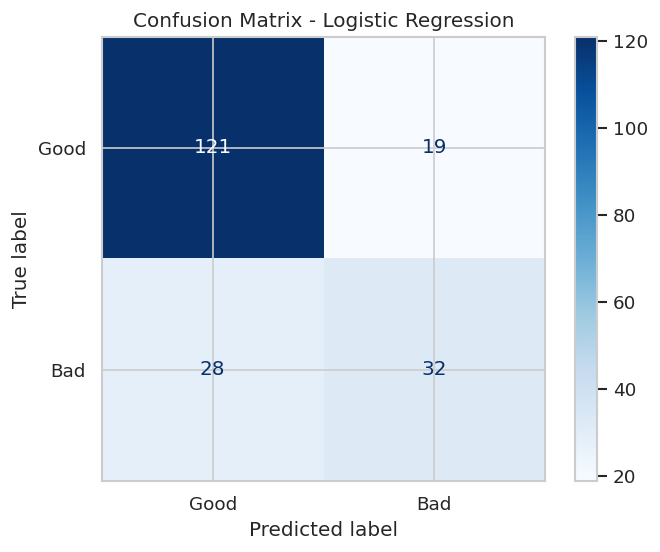


===== Random Forest =====
Precision : 0.750
Recall    : 0.450
F1-Score  : 0.562
ROC-AUC   : 0.816
              precision    recall  f1-score   support

        Good       0.80      0.94      0.86       140
         Bad       0.75      0.45      0.56        60

    accuracy                           0.79       200
   macro avg       0.77      0.69      0.71       200
weighted avg       0.78      0.79      0.77       200



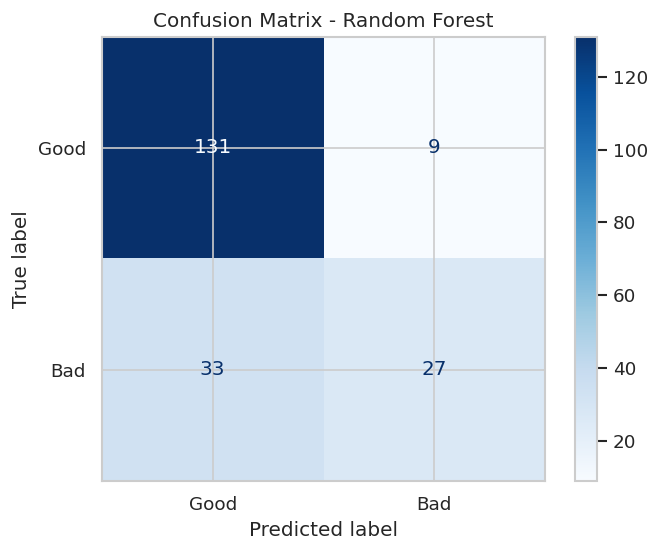

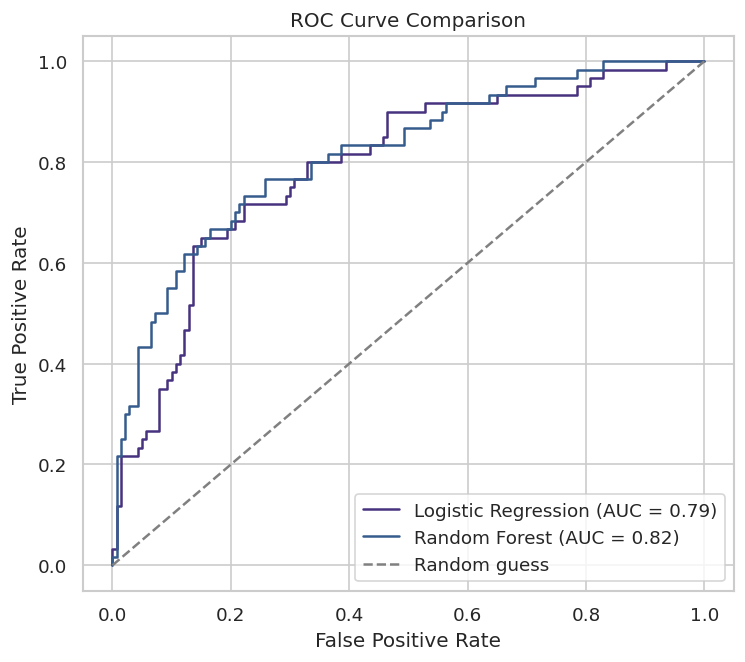


Saved plots: confusion matrices + roc_curve_comparison.png

Final Metrics Table:


,Precision,Recall,F1-Score,ROC-AUC
Model,,,,
Logistic Regression,0.627,0.533,0.577,0.791
Random Forest,0.750,0.450,0.562,0.816



Model and scaler saved as .pkl files.


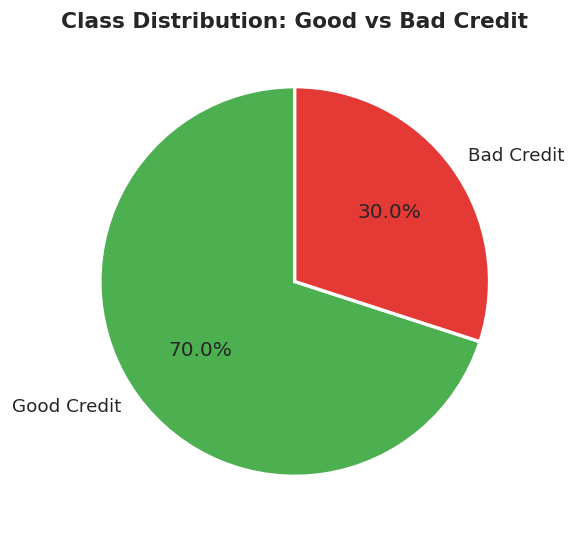

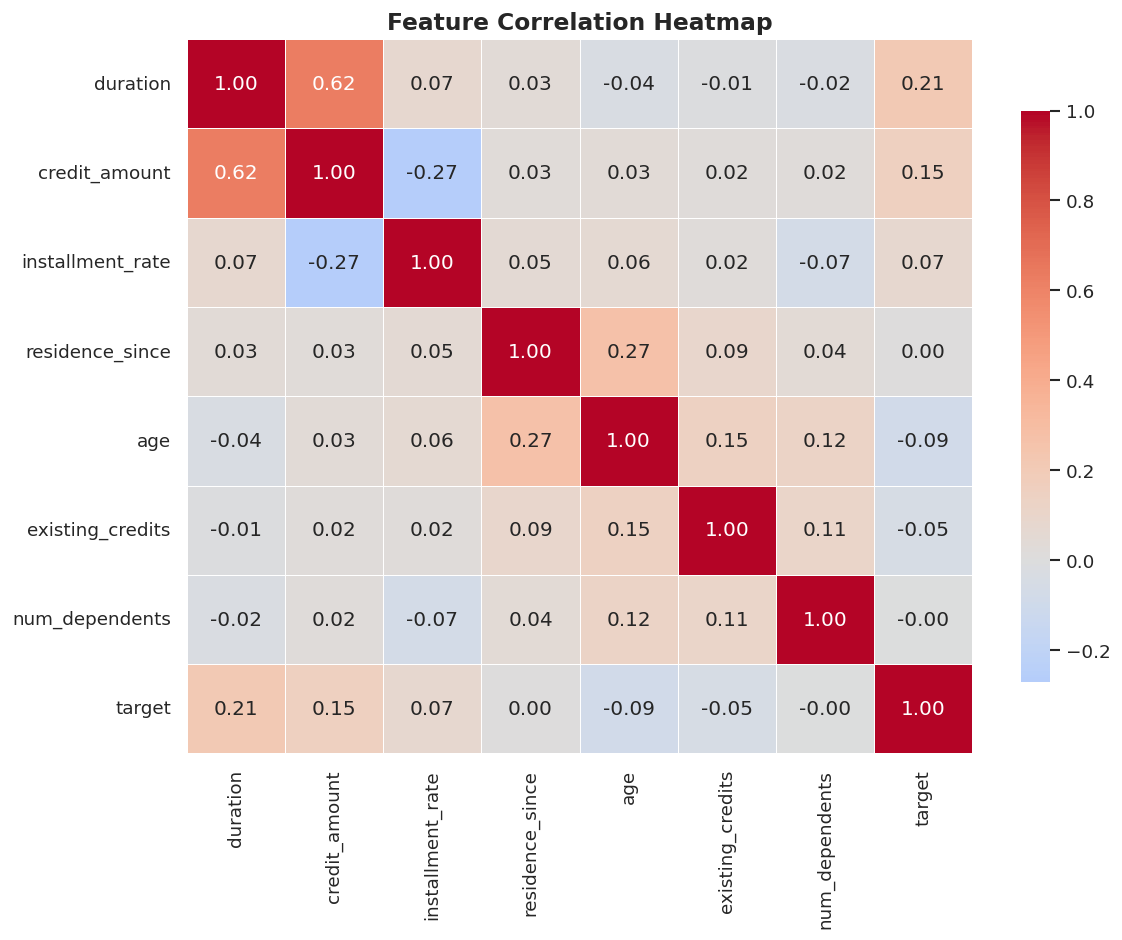

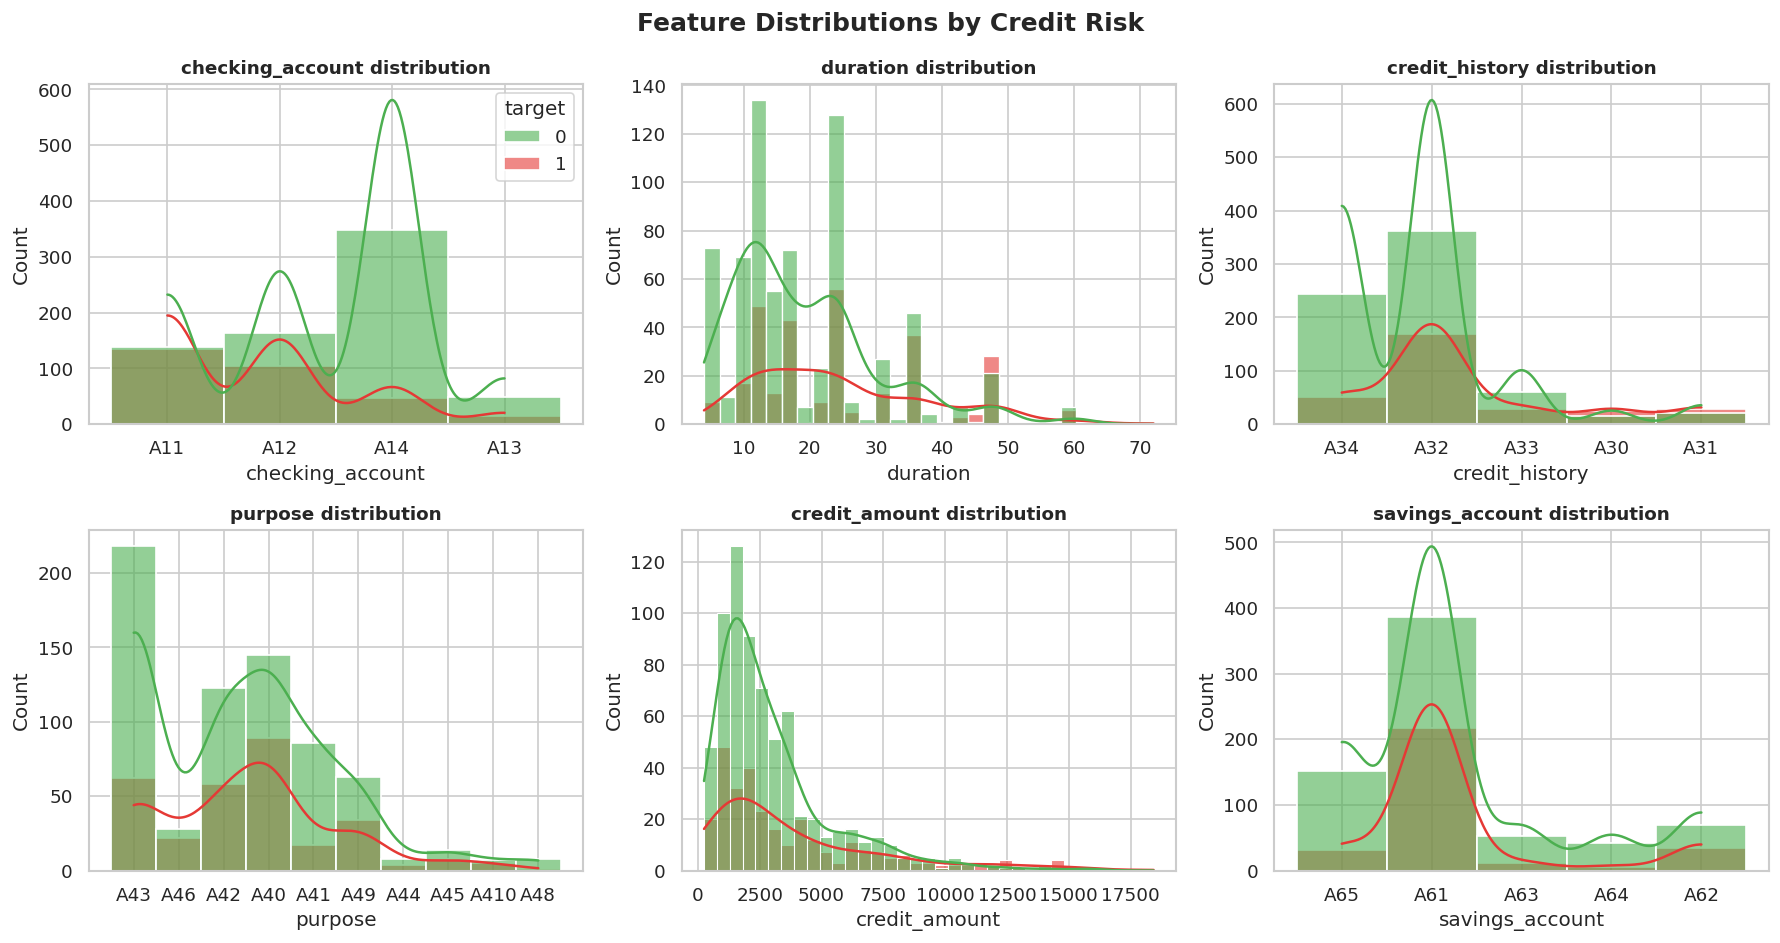

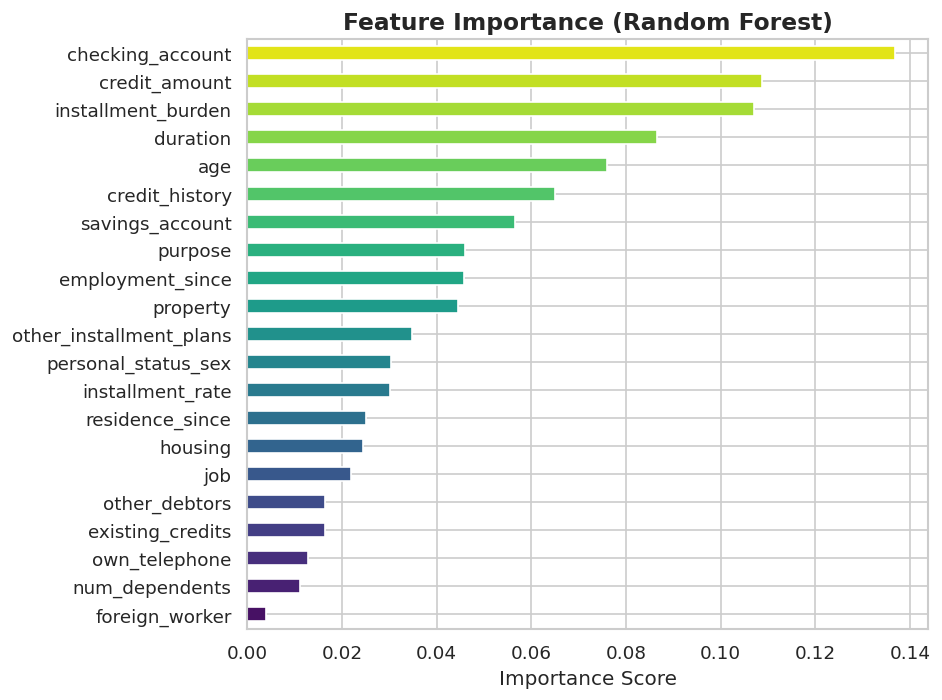

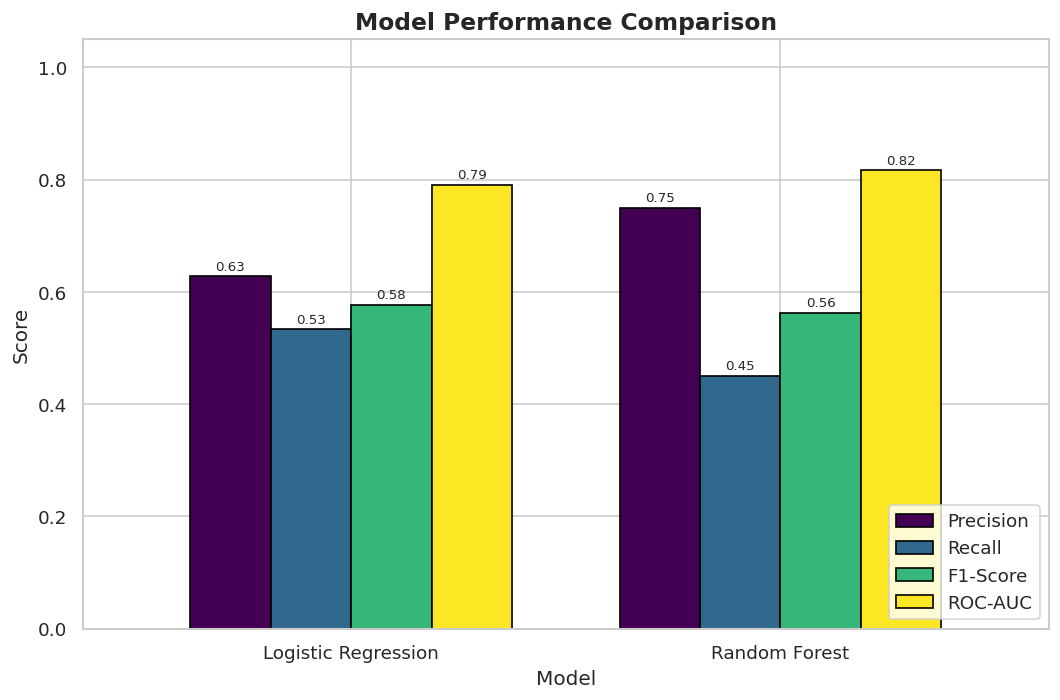


Saved visualizations:
  1_class_distribution.png
  2_correlation_heatmap.png
  3_feature_distributions.png
  6_feature_importance.png
  7_metrics_comparison.png


In [26]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_auc_score,
    roc_curve,
    precision_score,
    recall_score,
    f1_score,
)
import joblib


RANDOM_STATE = 42

def load_data():
    """
    Try to load the real UCI German Credit dataset.
    If that fails (no internet), generate a realistic synthetic dataset
    with the same kind of features (income, debt, payment history, etc.)
    so the pipeline still works end-to-end.
    """
    url = (
        "https://archive.ics.uci.edu/ml/machine-learning-databases/"
        "statlog/german/german.data"
    )
    columns = [
        "checking_account", "duration", "credit_history", "purpose",
        "credit_amount", "savings_account", "employment_since",
        "installment_rate", "personal_status_sex", "other_debtors",
        "residence_since", "property", "age", "other_installment_plans",
        "housing", "existing_credits", "job", "num_dependents",
        "own_telephone", "foreign_worker", "target"
    ]

    try:
        df = pd.read_csv(url, sep=" ", header=None, names=columns)
        print(" Loaded REAL dataset: UCI German Credit Data")
        df["target"] = df["target"].map({1: 0, 2: 1})  # 1 = bad credit risk
        return df, True

    except Exception as e:
        print(f" Could not download real dataset ({e}).")
        print(" Falling back to a synthetic dataset with similar structure.")
        return generate_synthetic_data(), False


def generate_synthetic_data(n_samples=1000):
    """Generate a synthetic but realistic credit dataset."""
    rng = np.random.default_rng(RANDOM_STATE)

    income = rng.normal(50000, 15000, n_samples).clip(10000, 150000)
    debt = rng.normal(15000, 8000, n_samples).clip(0, 80000)
    age = rng.integers(18, 70, n_samples)
    credit_amount = rng.normal(5000, 3000, n_samples).clip(500, 20000)
    duration_months = rng.integers(6, 60, n_samples)
    num_existing_credits = rng.integers(1, 5, n_samples)
    late_payments = rng.poisson(1.0, n_samples)
    employment_years = rng.integers(0, 30, n_samples)

    debt_to_income = debt / income




    risk_score = (
        (debt_to_income * 3)
        + (late_payments * 0.5)
        - (employment_years * 0.03)
        - (income / 100000)
        + (credit_amount / 20000)
        + rng.normal(0, 0.3, n_samples)
    )
    target = (risk_score > np.median(risk_score)).astype(int)  # 1 = bad risk


    df = pd.DataFrame({
        "income": income,
        "debt": debt,
        "age": age,
        "credit_amount": credit_amount,
        "duration_months": duration_months,
        "num_existing_credits": num_existing_credits,
        "late_payments": late_payments,
        "employment_years": employment_years,
        "debt_to_income": debt_to_income,
        "target": target,
    })
    return df






def preprocess(df, is_real_dataset):
    df = df.copy()

    if is_real_dataset:

        cat_cols = df.select_dtypes(include="object").columns
        for col in cat_cols:
            df[col] = LabelEncoder().fit_transform(df[col])


        df["installment_burden"] = df["credit_amount"] / (df["duration"] + 1)

    X = df.drop(columns=["target"])
    y = df["target"]

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
    )

    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    return X_train_scaled, X_test_scaled, y_train, y_test, scaler, X.columns




def train_models(X_train, y_train):
    log_reg = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)
    log_reg.fit(X_train, y_train)

    rf = RandomForestClassifier(
        n_estimators=200, max_depth=8, random_state=RANDOM_STATE
    )
    rf.fit(X_train, y_train)

    return {"Logistic Regression": log_reg, "Random Forest": rf}




def evaluate_models(models, X_test, y_test):
    all_metrics = []

    for name, model in models.items():
        y_pred = model.predict(X_test)
        y_proba = model.predict_proba(X_test)[:, 1] # Need this for AUC later


        precision = precision_score(y_test, y_pred)
        recall = recall_score(y_test, y_pred)
        f1 = f1_score(y_test, y_pred)
        auc = roc_auc_score(y_test, y_proba)

        print(f"\n===== {name} =====")
        print(f"Precision : {precision:.3f}")
        print(f"Recall    : {recall:.3f}")
        print(f"F1-Score  : {f1:.3f}")
        print(f"ROC-AUC   : {auc:.3f}")
        print(classification_report(y_test, y_pred, target_names=["Good", "Bad"]))


        all_metrics.append({
            "Model": name,
            "Precision": precision,
            "Recall": recall,
            "F1-Score": f1,
            "ROC-AUC": auc,
        })


        cm = confusion_matrix(y_test, y_pred)
        disp = ConfusionMatrixDisplay(cm, display_labels=["Good", "Bad"])
        disp.plot(cmap="Blues")
        plt.title(f"Confusion Matrix - {name}")
        plt.savefig(f"confusion_matrix_{name.replace(' ', '_')}.png", bbox_inches="tight")
        plt.show() # Show this confusion matrix


    plt.figure(figsize=(7, 6))
    for name, model in models.items():
        y_proba = model.predict_proba(X_test)[:, 1]
        fpr, tpr, _ = roc_curve(y_test, y_proba)
        auc = roc_auc_score(y_test, y_proba)
        plt.plot(fpr, tpr, label=f"{name} (AUC = {auc:.2f})")

    plt.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Random guess")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("ROC Curve Comparison")
    plt.legend()
    plt.savefig("roc_curve_comparison.png", bbox_inches="tight")
    plt.show()

    print("\nSaved plots: confusion matrices + roc_curve_comparison.png")


    metrics_df = pd.DataFrame(all_metrics).set_index("Model")
    return metrics_df


# ---------------------------------------------------------------------
# EXTRA VISUALIZATIONS (class balance, correlation, distributions,
# feature importance, metrics comparison bar chart)
# ---------------------------------------------------------------------
def plot_class_balance(df):
    plt.figure(figsize=(5, 5))
    counts = df["target"].value_counts().sort_index()
    labels = ["Good Credit", "Bad Credit"]
    colors = ["#4CAF50", "#E53935"]
    plt.pie(counts, labels=labels, autopct="%1.1f%%", colors=colors,
            startangle=90, wedgeprops={"edgecolor": "white", "linewidth": 2})
    plt.title("Class Distribution: Good vs Bad Credit", fontsize=13, weight="bold")
    plt.tight_layout()
    plt.savefig("1_class_distribution.png", bbox_inches="tight")
    plt.show()


def plot_correlation_heatmap(df):
    plt.figure(figsize=(10, 8))
    corr = df.corr(numeric_only=True)
    sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0,
                linewidths=0.5, cbar_kws={"shrink": 0.8})
    plt.title("Feature Correlation Heatmap", fontsize=14, weight="bold")
    plt.tight_layout()
    plt.savefig("2_correlation_heatmap.png", bbox_inches="tight")
    plt.show()


def plot_feature_distributions(df, feature_names):
    key_features = list(feature_names)[:6]
    fig, axes = plt.subplots(2, 3, figsize=(15, 8))
    axes = axes.flatten()
    for i, col in enumerate(key_features):
        sns.histplot(data=df, x=col, hue="target", kde=True, ax=axes[i],
                     palette=["#4CAF50", "#E53935"], alpha=0.6, legend=(i == 0))
        axes[i].set_title(f"{col} distribution", fontsize=11, weight="bold")
    if len(key_features) < len(axes):
        for j in range(len(key_features), len(axes)):
            fig.delaxes(axes[j])
    plt.suptitle("Feature Distributions by Credit Risk", fontsize=15, weight="bold")
    plt.tight_layout()
    plt.savefig("3_feature_distributions.png", bbox_inches="tight")
    plt.show()


def plot_feature_importance(rf_model, feature_names):
    importances = pd.Series(rf_model.feature_importances_, index=feature_names)
    importances = importances.sort_values(ascending=True)
    plt.figure(figsize=(8, 6))
    importances.plot(kind="barh", color=sns.color_palette("viridis", len(importances)))
    plt.title("Feature Importance (Random Forest)", fontsize=14, weight="bold")
    plt.xlabel("Importance Score")
    plt.tight_layout()
    plt.savefig("6_feature_importance.png", bbox_inches="tight")
    plt.show()


def plot_metrics_comparison(metrics_df):
    ax = metrics_df.plot(kind="bar", figsize=(9, 6), colormap="viridis",
                          edgecolor="black", width=0.75)
    plt.title("Model Performance Comparison", fontsize=14, weight="bold")
    plt.ylabel("Score")
    plt.ylim(0, 1.05)
    plt.xticks(rotation=0)
    plt.legend(loc="lower right")
    for container in ax.containers:
        ax.bar_label(container, fmt="%.2f", fontsize=8, padding=2)
    plt.tight_layout()
    plt.savefig("7_metrics_comparison.png", bbox_inches="tight")
    plt.show()



def main():
    df, is_real = load_data()
    print(f"\nDataset shape: {df.shape}")
    print(df.head())
    display(df.head())

    X_train, X_test, y_train, y_test, scaler, feature_names = preprocess(df, is_real)
    models = train_models(X_train, y_train)
    metrics_df = evaluate_models(models, X_test, y_test)


    print("\nFinal Metrics Table:")
    display(metrics_df.round(3))

    # I used (Random Forest) + scaler for later use. those kind of best model.
    best_model = models["Random Forest"]
    joblib.dump(best_model, "credit_scoring_model.pkl")
    joblib.dump(scaler, "credit_scoring_scaler.pkl")
    print("\nModel and scaler saved as .pkl files.")

    # --- Generating all visualizations ---
    plot_class_balance(df)
    plot_correlation_heatmap(df)
    plot_feature_distributions(df, feature_names)
    plot_feature_importance(best_model, feature_names)
    plot_metrics_comparison(metrics_df)

    print("\nSaved visualizations:")
    print("  1_class_distribution.png\n  2_correlation_heatmap.png")
    print("  3_feature_distributions.png\n  6_feature_importance.png")
    print("  7_metrics_comparison.png")


if __name__ == "__main__":
    main()

# ----♻️♻️♻️♻️----

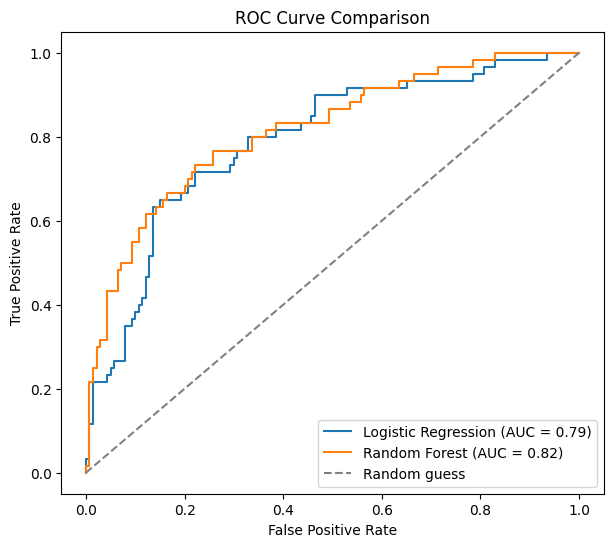

In [ ]:
from IPython.display import Image
Image('roc_curve_comparison.png')

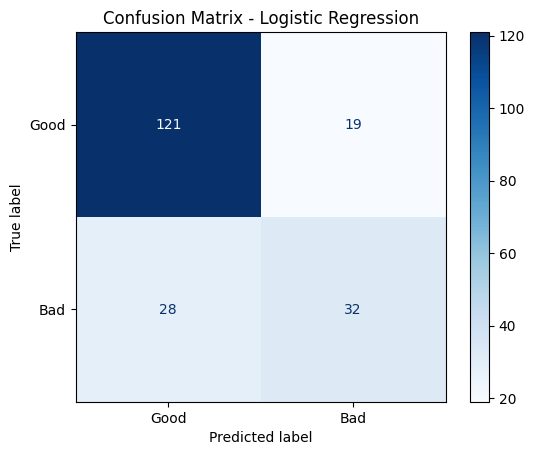

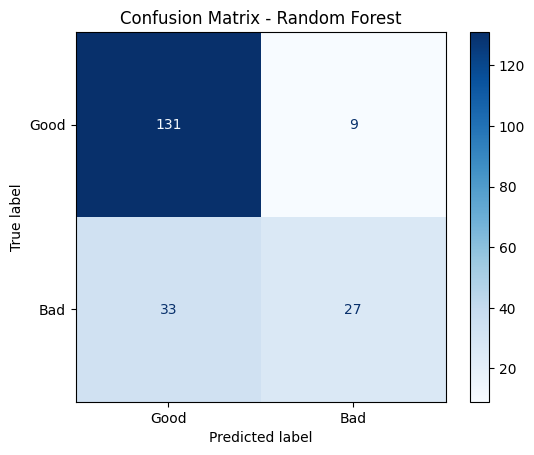

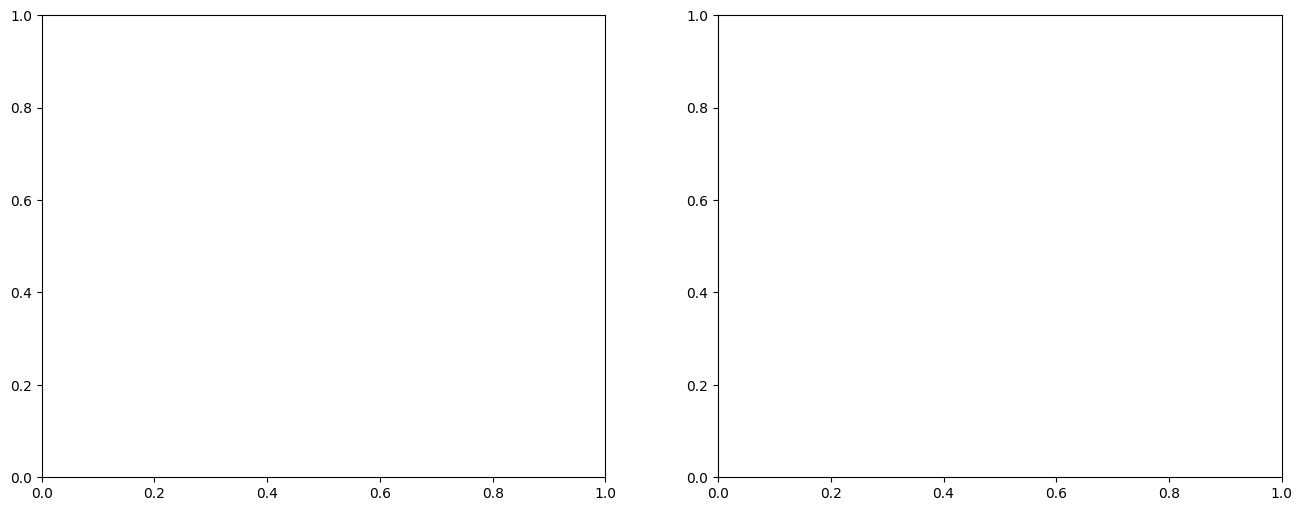

In [ ]:
from IPython.display import Image, display
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Display Logistic Regression Confusion Matrix
img_lr = Image('confusion_matrix_Logistic_Regression.png')
display(img_lr)

# Display Random Forest Confusion Matrix
img_rf = Image('confusion_matrix_Random_Forest.png')
display(img_rf)

### 📊 Class Distribution: Good vs Bad Credit

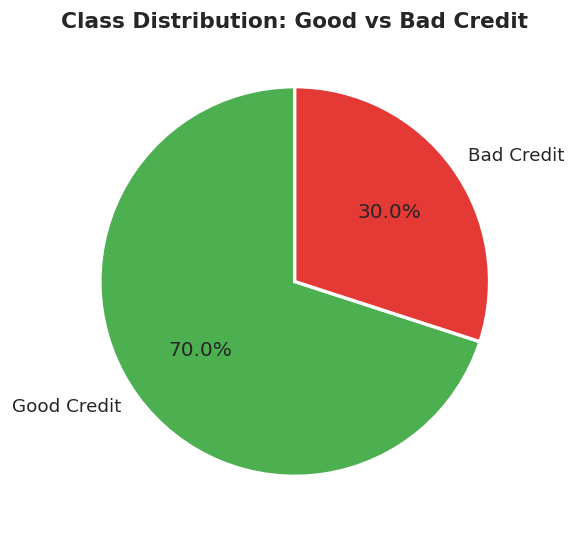

### 🔥 Feature Correlation Heatmap

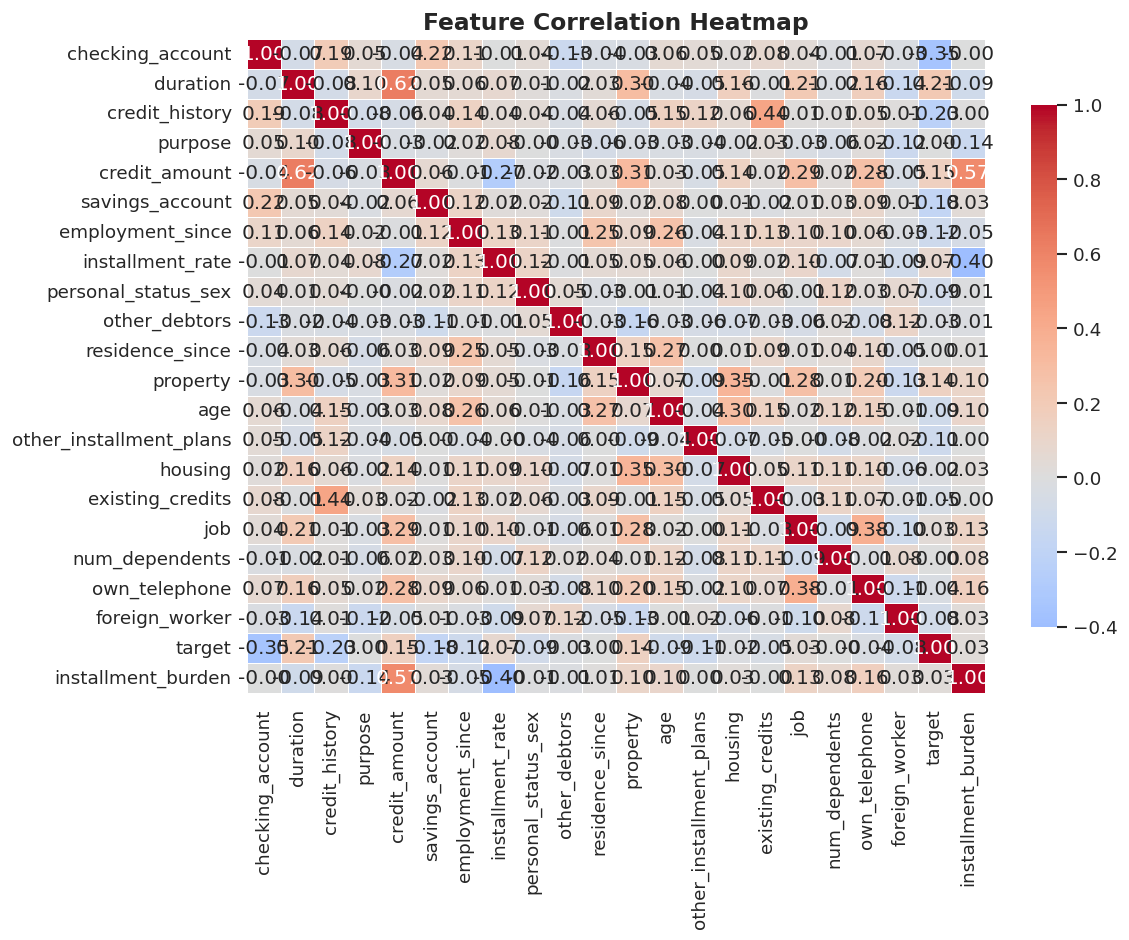

### 📈 Feature Distributions by Credit Risk

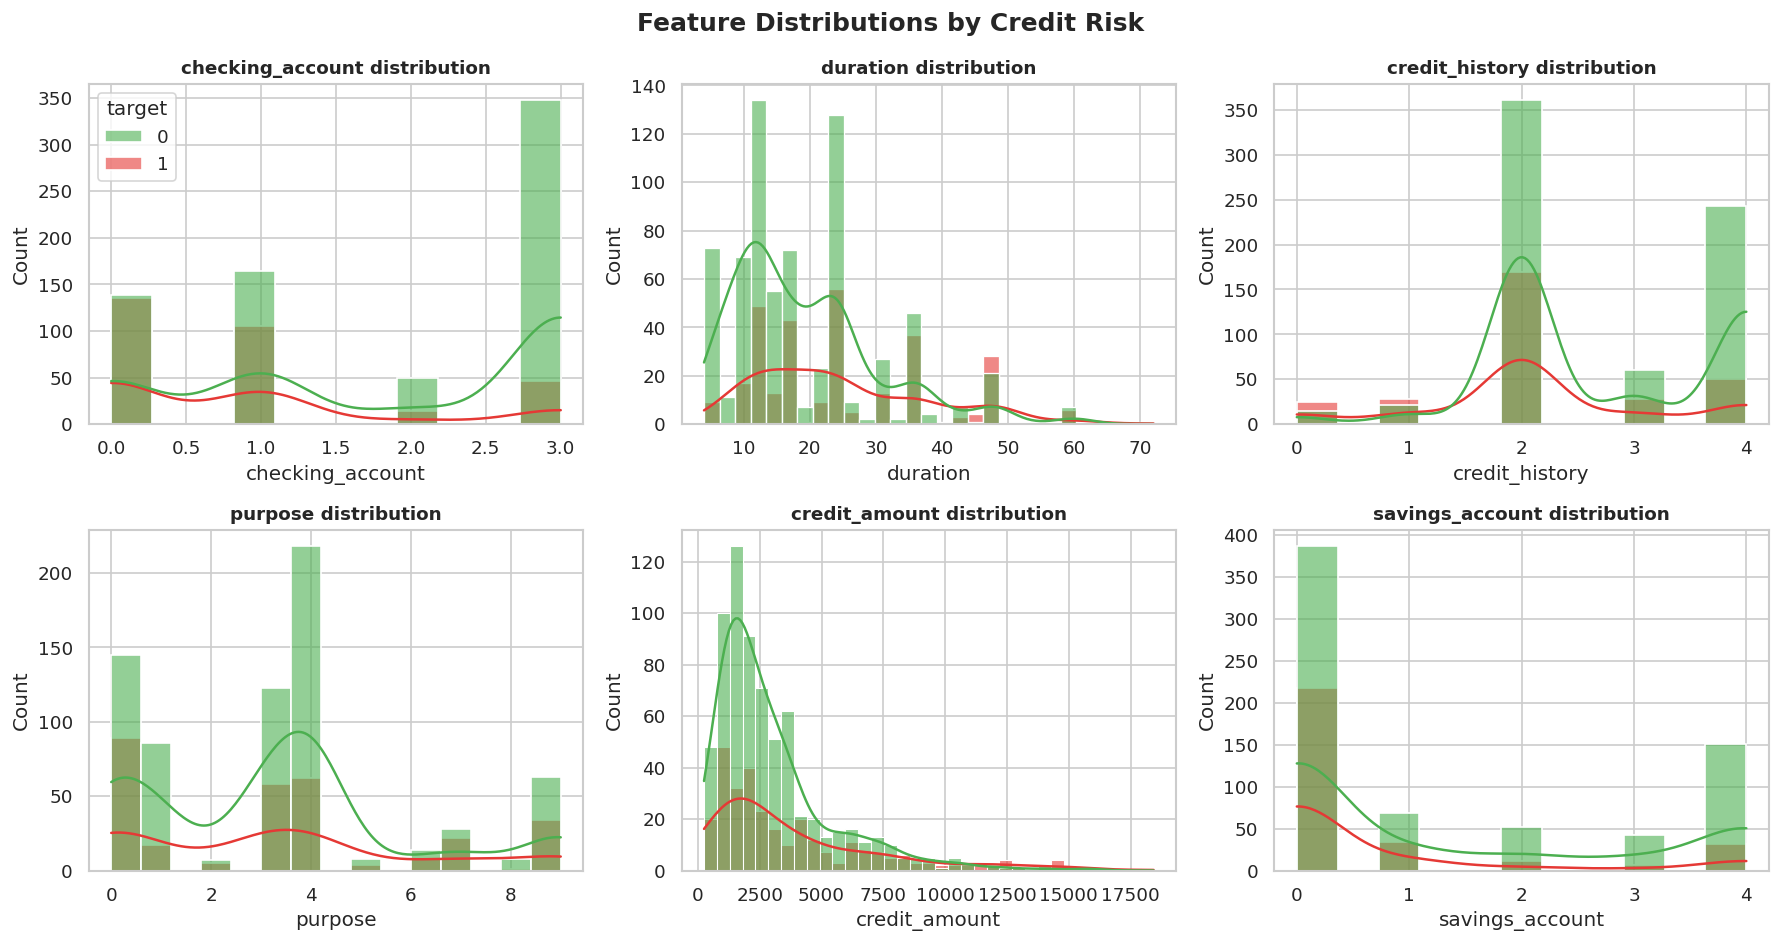

### 🧩 Confusion Matrices

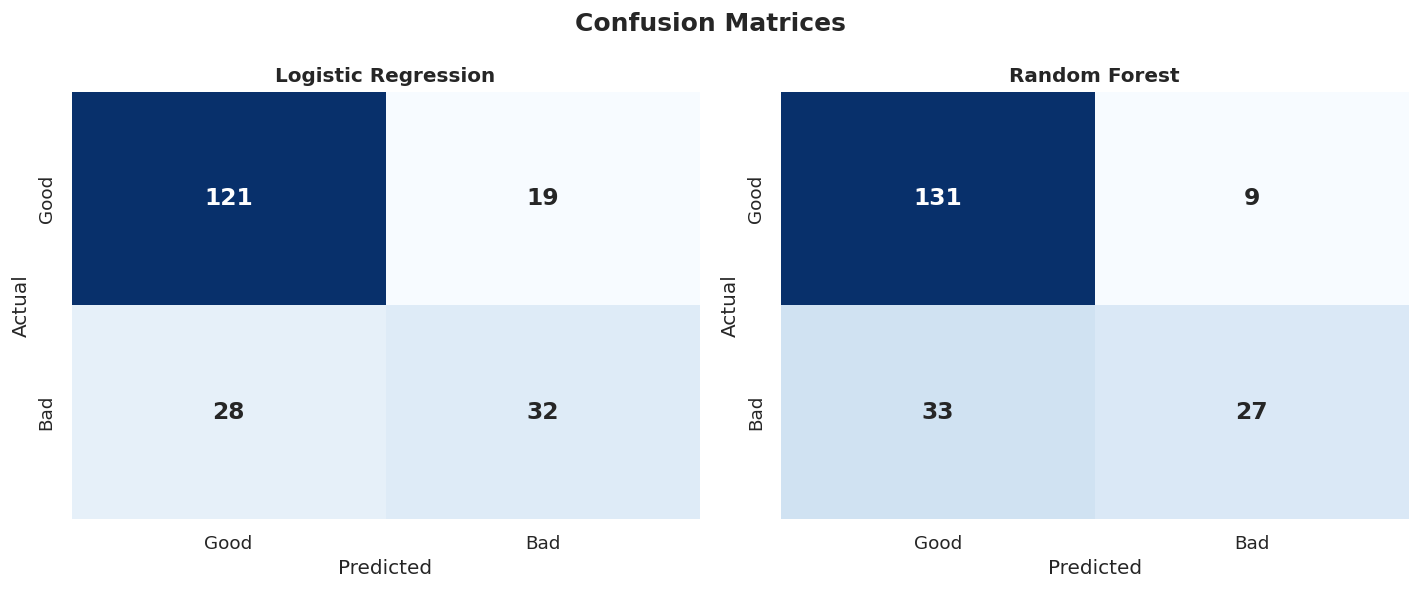

### 📉 ROC Curve Comparison

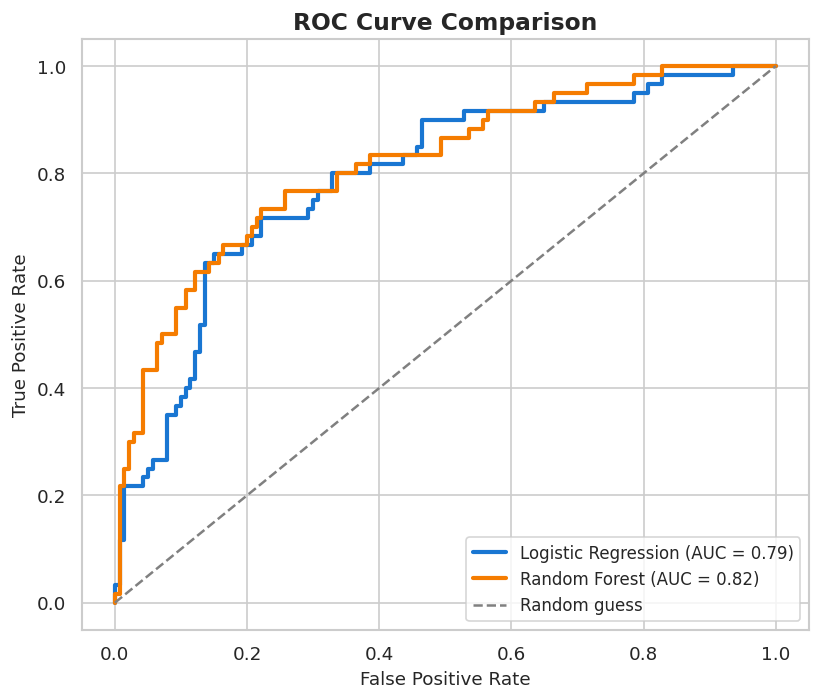

### 🌟 Feature Importance (Random Forest)

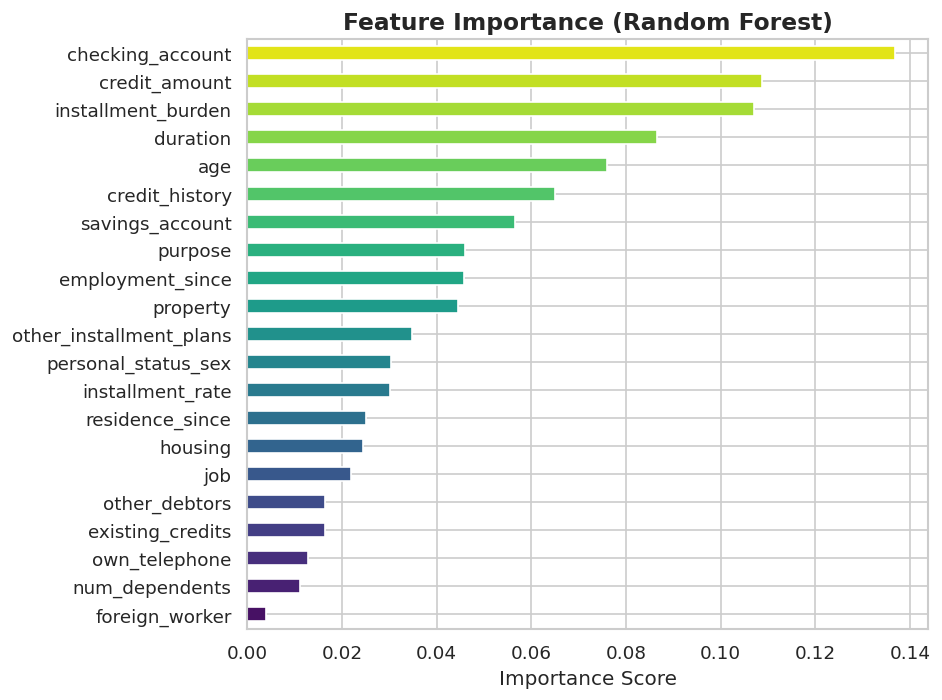

### 🏆 Model Performance Comparison

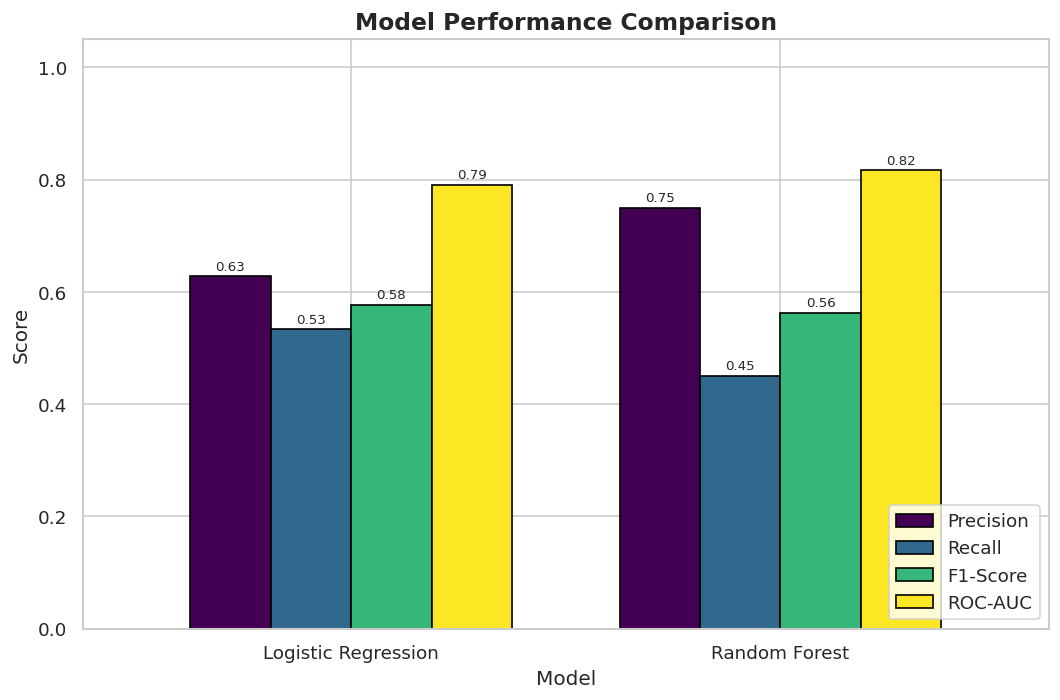

In [25]:
from IPython.display import Image, display, Markdown

visualizations = [
    ("1_class_distribution.png", "📊 Class Distribution: Good vs Bad Credit"),
    ("2_correlation_heatmap.png", "🔥 Feature Correlation Heatmap"),
    ("3_feature_distributions.png", "📈 Feature Distributions by Credit Risk"),
    ("4_confusion_matrices.png", "🧩 Confusion Matrices"),
    ("5_roc_curve_comparison.png", "📉 ROC Curve Comparison"),
    ("6_feature_importance.png", "🌟 Feature Importance (Random Forest)"),
    ("7_metrics_comparison.png", "🏆 Model Performance Comparison"),
]

for filename, title in visualizations:
    display(Markdown(f"### {title}"))
    display(Image(filename=filename))
